In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
from matplotlib_venn import venn2, venn3, venn3_unweighted
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import matplotlib.patches as patches


from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

sc.settings.verbosity = 2

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.42 GB, difference +2.42 GB
CPU times: user 460 ms, sys: 2.02 s, total: 2.48 s
Wall time: 5.57 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [3]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

adata.X = adata.layers['log_norm'].copy()

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs[['phase']].head()

calculating cell cycle phase
computing score 'S_score'
    finished (0:00:01)
computing score 'G2M_score'
    finished (0:00:01)
CPU times: user 1.79 s, sys: 1.39 s, total: 3.18 s
Wall time: 3.21 s


,phase
AAACCAAAGCAACTGC_hybrid,G2M
AAACCAAAGTAGGGCA_hybrid,S
AAACCAAAGTCTAGGC_hybrid,G1
AAACCATTCACGTAAT_hybrid,G2M
AAACCATTCAGGCAGA_hybrid,G2M


In [4]:
# get just mmMYOD1 and control cells

mdata = adata[adata.obs['pooled_condition'].isin(['mmMYOD1', 'Control']), :].copy()
mdata

AnnData object with n_obs × n_vars = 9157 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std

In [9]:
print(mdata.obs['dataset'].value_counts())
mdata.obs.tail()

dataset
Control    6902
Hybrid     2255
Name: count, dtype: int64


,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,mt_outlier,n_genes,doublet_score,predicted_doublet,S_score,G2M_score,phase,leiden,cluster_str,leiden_split
TGTGGTCAGTGAGCCT_control,NaN,NaN,NaN,G1,4.0,0.75,3.0,0.0,1.0,Control,...,False,2571,0.028961,False,-0.553541,-1.908063,G1,4,C5,C2
TGTGGTTGTAGCCCTA_control,NaN,NaN,NaN,G1,6.0,1.00,6.0,0.0,0.0,Control,...,False,3213,0.202797,False,-1.198001,-3.758561,G1,4,C5,C2
TGTGGTTGTTGAAGGC_control,NaN,NaN,NaN,G1,5.0,1.00,5.0,0.0,0.0,Control,...,False,3578,0.082431,False,-1.158401,-3.554689,G1,4,C5,C2
TGTGTTAGTTGGTAAG_control,NaN,NaN,NaN,S,5.0,0.60,2.0,0.0,3.0,Control,...,False,2433,0.032727,False,-0.787688,-1.750511,G1,4,C5,C2
TGTGTTGAGCCTATCT_control,NaN,NaN,NaN,S,4.0,0.50,1.0,1.0,2.0,Control,...,False,3704,0.060788,False,-0.866395,-0.191349,G1,2,C3,C1


In [15]:
# load fib pseudotime from CS
df = pd.read_csv("scfib_pseudotime_cooper.csv")
df = df.rename(columns={'Unnamed: 0': 'cell_id'})

df['cell_id_new'] = df['cell_id'].str.split('-').str[0] + '_control'

df = df.set_index('cell_id_new')

df = df.drop(columns='cell_id')

print(df.shape)
df.head()

(6895, 5)


,cluster_phase,barcoded_phase,G1_stage,dpt_pseudotime,global_ordering
cell_id_new,,,,,
AAACCAAAGGGTAGCA_control,S,G2M,NaN,0.910904,4893.0
AAACCAAAGTAAGGGT_control,G1,G1,late,0.101642,881.0
AAACCATTCAGGTAGG_control,G2M,G1,NaN,0.967784,6694.0
AAACCATTCCAGCCCT_control,G1,S,late,0.201039,2530.0
AAACCATTCGTGACCG_control,G1,G1,early,0.066694,344.0


In [16]:
mdata.obs = mdata.obs.merge(
    df,
    how='left',
    left_index=True,
    right_index=True,
)

print(mdata)
mdata.obs.head()

AnnData object with n_obs × n_vars = 9157 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'cluster_phase', 'barcoded_phase', 'G1_stage', 'dpt_pseudotime', 'global_ordering'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pc

,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,G2M_score,phase,leiden,cluster_str,leiden_split,cluster_phase,barcoded_phase,G1_stage,dpt_pseudotime,global_ordering
AAACCAAAGTAGGGCA_hybrid,14.0,1.0,1.0,MYOD,16.0,0.875000,NaN,NaN,NaN,Hybrid,...,-0.390685,S,0,C1,M1,NaN,NaN,NaN,NaN,NaN
AAACCCGCACCATAGG_hybrid,22.0,0.0,1.0,MYOD,23.0,0.956522,NaN,NaN,NaN,Hybrid,...,-1.535523,G1,0,C1,M2,NaN,NaN,NaN,NaN,NaN
AAACCCGCATCCAATT_hybrid,22.0,2.0,1.0,MYOD,25.0,0.880000,NaN,NaN,NaN,Hybrid,...,3.495272,G2M,0,C1,M1,NaN,NaN,NaN,NaN,NaN
AAACCCTGTAACGACA_hybrid,24.0,0.0,1.0,MYOD,25.0,0.960000,NaN,NaN,NaN,Hybrid,...,-0.384040,G1,0,C1,M2,NaN,NaN,NaN,NaN,NaN
AAACGGGTCGTAATGT_hybrid,25.0,0.0,0.0,MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,2.057884,G2M,1,C2,M1,NaN,NaN,NaN,NaN,NaN


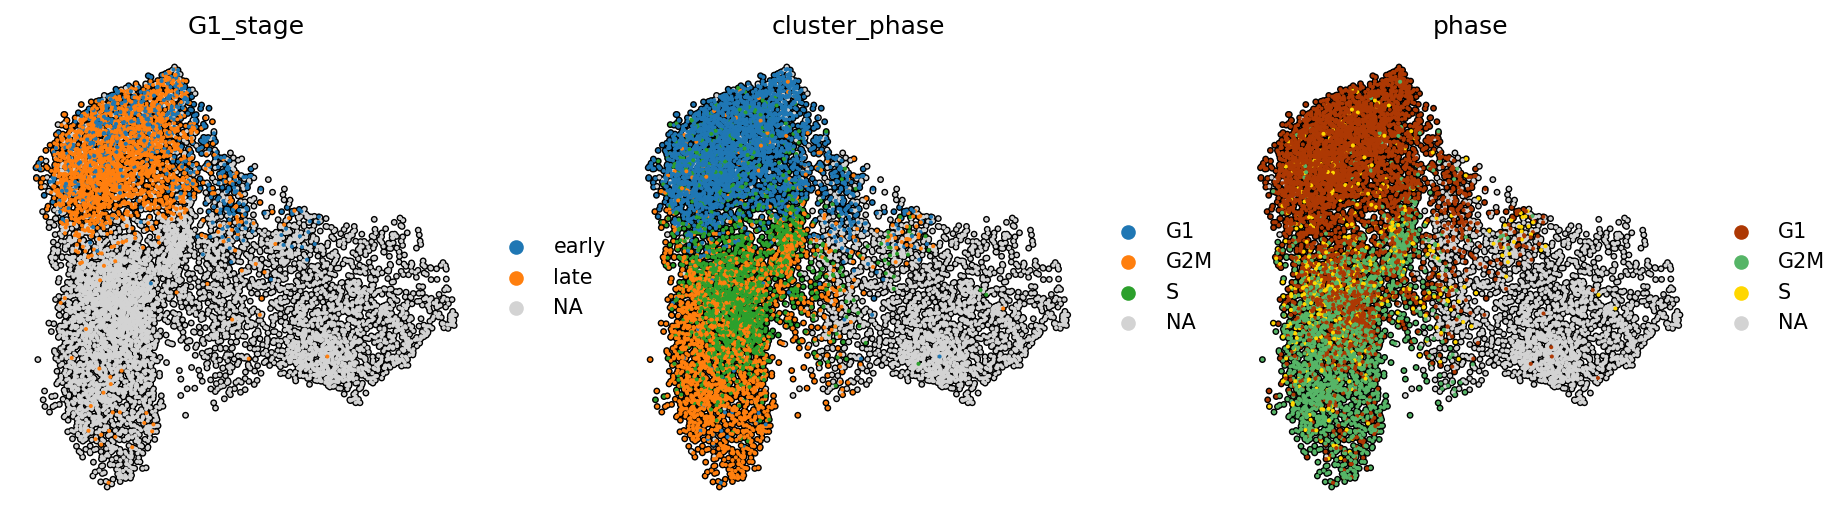

In [18]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

mask = mdata.obs['pooled_condition'] == 'Control'

sc.pl.umap(
    mdata,
    color=['G1_stage', 'cluster_phase', 'phase'],
    mask_obs=mask,
    size=15,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

In [20]:
from sklearn.metrics import confusion_matrix


df = mdata.obs[['assigned_condition', 'dataset', 'S_score', 'G2M_score', 'phase', 'cluster_phase']].copy()

df = df[df['dataset'] == 'Control']
print(f'Total cells: {df.shape[0]}')

# drop rows with missing labels
df = df.dropna(subset=['assigned_condition', 'phase', 'cluster_phase'])

print(f'After dropping missing labels: {df.shape[0]}')
df.head()

Total cells: 6902
After dropping missing labels: 6708


,assigned_condition,dataset,S_score,G2M_score,phase,cluster_phase
AAACCAAAGGGTAGCA_control,G2M,Control,-0.154577,1.103821,G2M,S
AAACCAAAGTAAGGGT_control,G1,Control,-0.831730,-2.102671,G1,G1
AAACCATTCAGGTAGG_control,G1,Control,-0.445596,0.907616,G2M,G2M
AAACCATTCCAGCCCT_control,S,Control,-0.968048,-3.990225,G1,G1
AAACCATTCGTGACCG_control,G1,Control,-0.902665,-2.358676,G1,G1


(3, 3)


,G1,S,G2M
G1,2825,0,0
S,1138,320,355
G2M,329,169,1572


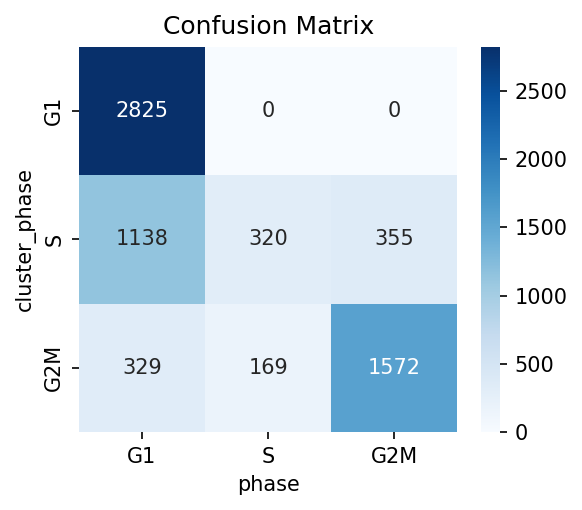

,G1,S,G2M
G1,1.000000,0.000000,0.000000
S,0.627689,0.176503,0.195808
G2M,0.158937,0.081643,0.759420


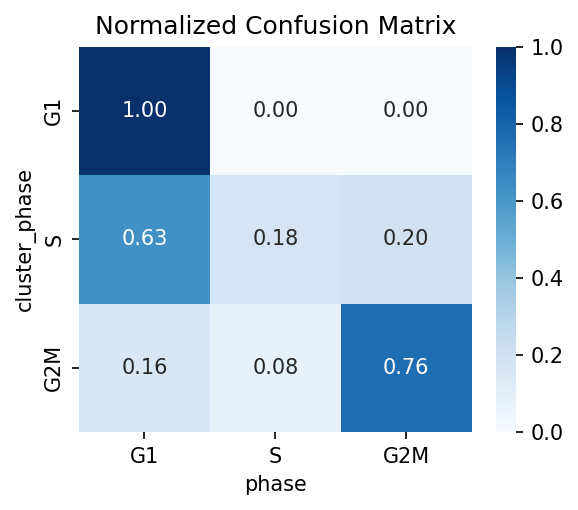

In [26]:
labels = ['G1', 'S', 'G2M']

# comp1 = 'assigned_condition' # y true
# comp2 = 'cluster_phase' # y pred

comp1 = 'cluster_phase' # y true
comp2 = 'phase' # y pred

cm = confusion_matrix(
    df[comp1], # y_true
    df[comp2], # y_pred
    labels=labels
)

# Convert to DataFrame for nicer plotting
cdf = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

print(cdf.shape)
display(cdf)


plt.figure(figsize=(4, 3.5), dpi=150)
sns.heatmap(
    cdf,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.ylabel(comp1)
plt.xlabel(comp2)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

cm_norm = confusion_matrix(
    df[comp1],
    df[comp2],
    labels=labels,
    normalize="true"
)

cndf = pd.DataFrame(
    cm_norm,
    index=labels,
    columns=labels
)

display(cndf)

plt.figure(figsize=(4, 3.5), dpi=150)
sns.heatmap(
    cndf,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True
)

plt.ylabel(comp1)
plt.xlabel(comp2)
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()